In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv("/home/aderham/delairshed/landcoverlabels.csv")
train,test=train_test_split(df,test_size=0.4,random_state=42)

classes=sorted(df["lclabel"].unique())
label_to_idx={label: i for i, label in enumerate(classes)}

train["label_idx"]=train["lclabel"].map(label_to_idx)
test["label_idx"]=test["lclabel"].map(label_to_idx)

In [21]:
class LandCoverDataset(Dataset):
    def __init__(self, df, imgdir):
        self.df=df.reset_index(drop=True)
        self.imgdir=imgdir

        self.transform=transforms.Compose([ transforms.Resize((128,128)), transforms.ToTensor()])

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):
        row=self.df.iloc[idx]
        imgpth=os.path.join(self.imgdir,row["filename"])
        image=Image.open(imgpth).convert("RGB")

        image=self.transform(image)
        label=row["label_idx"]

        return image, label

In [22]:
trainds=LandCoverDataset(train,"/home/aderham/delairshed/filtered_rgb/")
testds=LandCoverDataset(test,"/home/aderham/delairshed/filtered_rgb/")

train_loader = DataLoader(trainds, batch_size=32, shuffle=True)
test_loader = DataLoader(testds, batch_size=32, shuffle=False)

In [23]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

In [51]:
num_classes = len(train["label_idx"].unique())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes).to(device)

In [52]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [53]:
epochs = 5

for epoch in range(epochs):
    model.train()
    
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
        _, preds = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    

    train_acc = 100 * correct / total
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Train Accuracy: {train_acc:.2f}%")

Epoch 1, Loss: 119.6952, Train Accuracy: 72.11%
Epoch 2, Loss: 88.2666, Train Accuracy: 80.60%
Epoch 3, Loss: 78.3611, Train Accuracy: 83.66%
Epoch 4, Loss: 68.4660, Train Accuracy: 85.07%
Epoch 5, Loss: 58.1545, Train Accuracy: 86.40%


In [54]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        # Accuracy calculation (your original)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Store for metrics
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


accuracy = 100 * correct / total

cm = confusion_matrix(all_labels, all_preds)


report = classification_report(all_labels, all_preds)


error_rate = 1 - (accuracy / 100)


print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Error Rate: {error_rate:.4f}")

print("\nConfusion Matrix:\n")
print(cm)

print("\nClassification Report:\n")
print(report)

Test Accuracy: 80.29%
Error Rate: 0.1971

Confusion Matrix:

[[ 318  314    0   16   34    0]
 [   4 2197    0    4   12    0]
 [   3   54    0    0    0    0]
 [   2   94    0   10    4    0]
 [   8   77    1    1   49    0]
 [   0    3    0    0    1    0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.47      0.63       682
           1       0.80      0.99      0.89      2217
           2       0.00      0.00      0.00        57
           4       0.32      0.09      0.14       110
           5       0.49      0.36      0.42       136
           6       0.00      0.00      0.00         4

    accuracy                           0.80      3206
   macro avg       0.43      0.32      0.34      3206
weighted avg       0.79      0.80      0.77      3206



/home/aderham/.venvs/espada/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aderham/.venvs/espada/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aderham/.venvs/espada/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

### Class imbalance is the likely cause of this warning

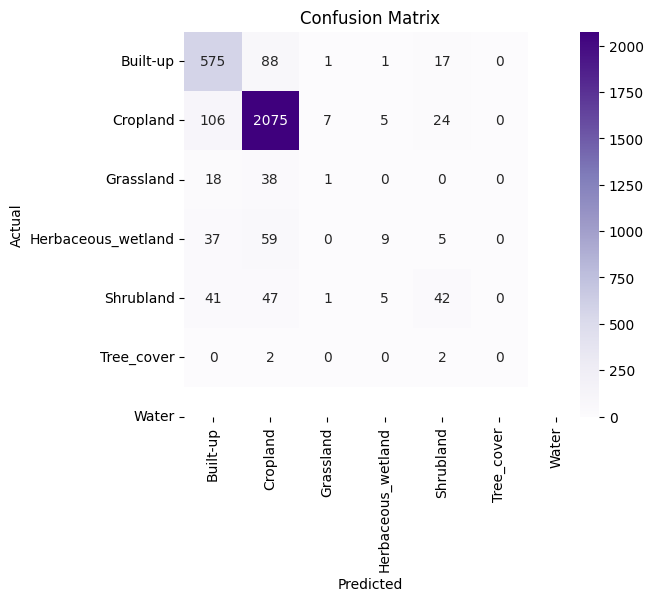

In [47]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Inference:

### The CNN model used with the Adam optimizer and on 5 epochs of training with a batch-size of 32 has yeilded reasonable performance.
### The training accuracy states 86.40% in the last epoch while the testing accuracy showcases 80.29% which shows slight overfitting. This can be taken care of by introducing regularization with respect to dropouts.

### A stratified approach towards the train-test split would also have a great deal in preventing the class imbalance issue the model is currently facing; the zero_division parameter warning.

### Slightly adjusting the learning rate and increasing epochs would also greatly aid in increasing the model performance.

### Data augmentation or deeper CNN can aid in improving the feature map created by the simple CNN.

### Using other varaints like Alexnet or ResNet18 may greatly improve the performance.

### A rigorous validation evaluation would aid a great deal in thoroughly tuning the hyperparameters.

### Increasing the training data would also aid the model in improving the overall performance.